### Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv('Stock_Price_Test.csv')

display(df.head())

,Date,Open,High,Low,Close,Volume
0,1/3/2017,778.81,789.63,775.80,786.14,"1,657,300"
1,1/4/2017,788.36,791.34,783.16,786.90,"1,073,000"
2,1/5/2017,786.08,794.48,785.02,794.02,"1,335,200"
3,1/6/2017,795.26,807.90,792.20,806.15,"1,640,200"
4,1/9/2017,806.40,809.97,802.83,806.65,"1,272,400"


## 1. Data Cleaning

In [2]:
# Fix data types
df['Date'] = pd.to_datetime(df['Date'])
df['Volume'] = df['Volume'].str.replace(',', '').astype(int)

# Drop missing values and duplicates
df = df.dropna().drop_duplicates(subset=['Date']).sort_values('Date').reset_index(drop=True)

# New columns
df['Daily Return (%)'] = (df['Close'] - df['Open']) / df['Open'] * 100
df['Price Range'] = df['High'] - df['Low']

print(f"Final shape: {df.shape}")
display(df.head())

Final shape: (20, 8)


,Date,Open,High,Low,Close,Volume,Daily Return (%),Price Range
0,2017-01-03,778.81,789.63,775.80,786.14,1657300,0.941179,13.83
1,2017-01-04,788.36,791.34,783.16,786.90,1073000,-0.185195,8.18
2,2017-01-05,786.08,794.48,785.02,794.02,1335200,1.010075,9.46
3,2017-01-06,795.26,807.90,792.20,806.15,1640200,1.369363,15.70
4,2017-01-09,806.40,809.97,802.83,806.65,1272400,0.031002,7.14


## 2. Summary Statistics

In [3]:
display(df[['Open', 'High', 'Low', 'Close', 'Volume']].describe())

,Open,High,Low,Close,Volume
count,20.000000,20.000000,20.000000,20.000000,2.000000e+01
mean,807.526000,811.926500,801.949500,807.904500,1.659895e+06
std,15.125428,14.381198,13.278607,13.210088,6.774747e+05
min,778.810000,789.630000,775.800000,786.140000,9.193000e+05
25%,802.965000,806.735000,797.427500,802.282500,1.248500e+06
50%,806.995000,808.640000,801.530000,806.110000,1.418050e+06
75%,809.560000,817.097500,804.477500,810.760000,1.743400e+06
max,837.810000,841.950000,827.010000,835.670000,3.246600e+06


### Correlation Between Price & Volume

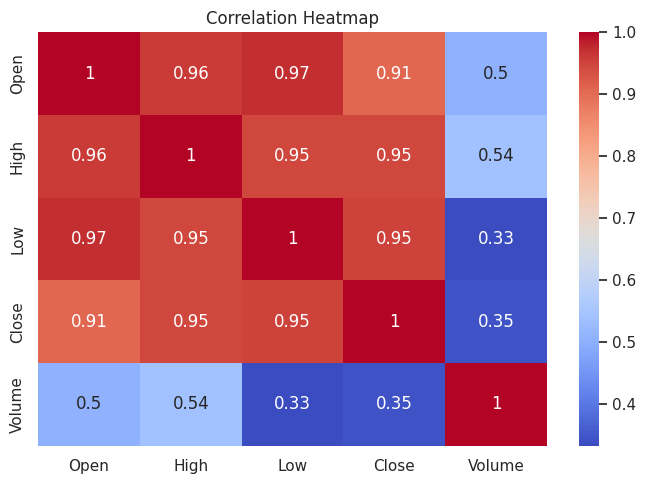

In [4]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[['Open', 'High', 'Low', 'Close', 'Volume']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Finding:** Prices are strongly correlated with each other, while volume moves fairly independently.

## 3. Closing Price Trend

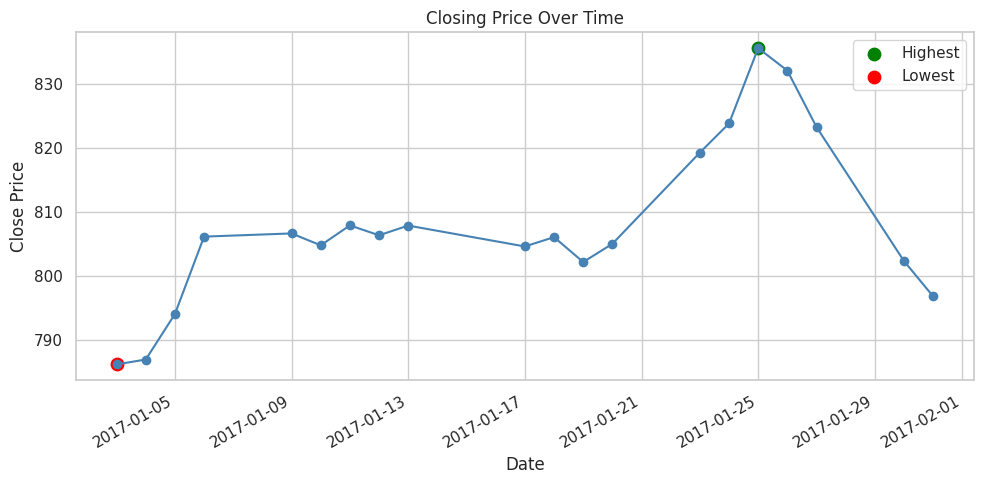

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Close'], marker='o', color='steelblue')

plt.scatter(df.loc[df['Close'].idxmax(), 'Date'], df['Close'].max(), color='green', s=80, label='Highest')
plt.scatter(df.loc[df['Close'].idxmin(), 'Date'], df['Close'].min(), color='red', s=80, label='Lowest')

plt.title('Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

**Finding:** The stock trends upward over the month, closing at its highest near the end and lowest near the start.

## 4. Daily Price Volatility

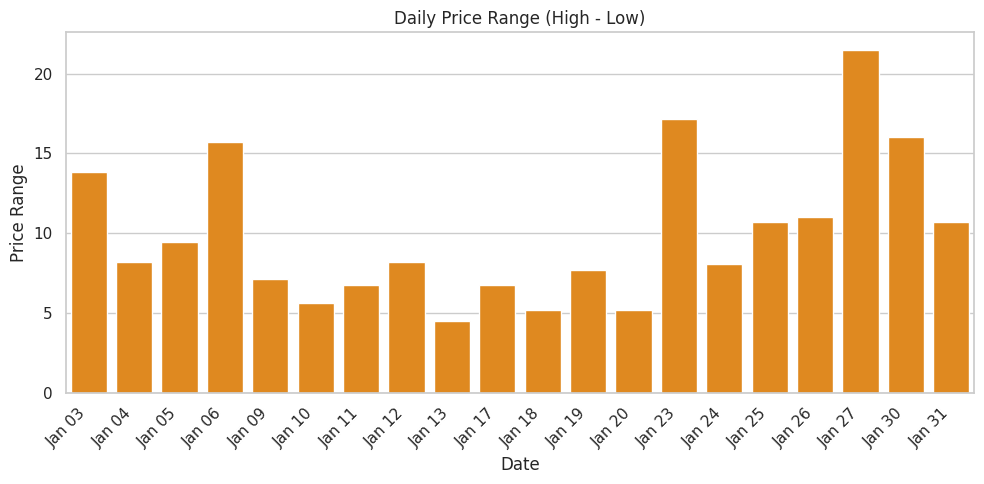

In [6]:
plt.figure(figsize=(10, 5))
sns.barplot(x=df['Date'].dt.strftime('%b %d'), y=df['Price Range'], color='darkorange')

plt.title('Daily Price Range (High - Low)')
plt.xlabel('Date')
plt.ylabel('Price Range')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding:** Volatility rises later in the month, with the widest price swing seen in late January.

## 5. Trading Volume

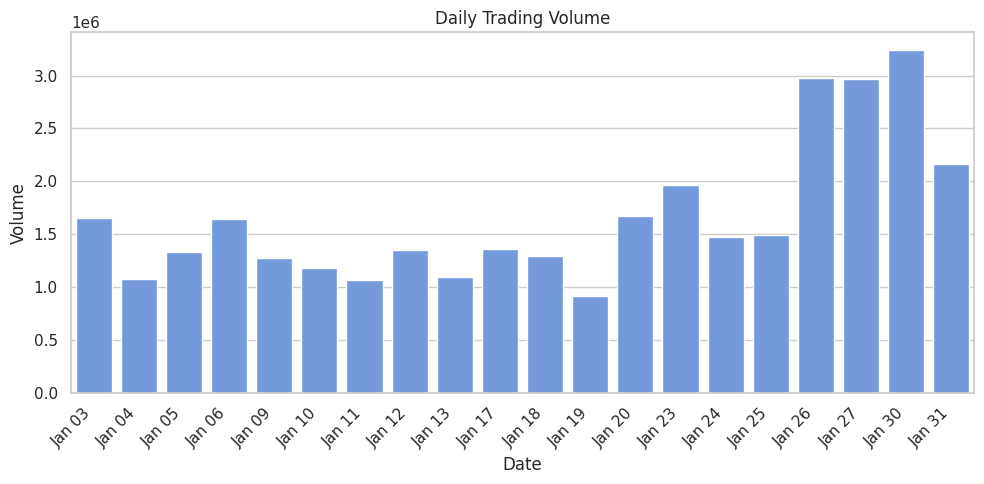

In [7]:
plt.figure(figsize=(10, 5))
sns.barplot(x=df['Date'].dt.strftime('%b %d'), y=df['Volume'], color='cornflowerblue')

plt.title('Daily Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding:** Volume spikes coincide with the days that had the largest price moves, both up and down.

## 6. Open vs. Close & Bullish/Bearish Days

/tmp/ipykernel_615/4184408875.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Trend', data=df, palette={'Bullish': 'seagreen', 'Bearish': 'indianred'}, ax=axes[1])


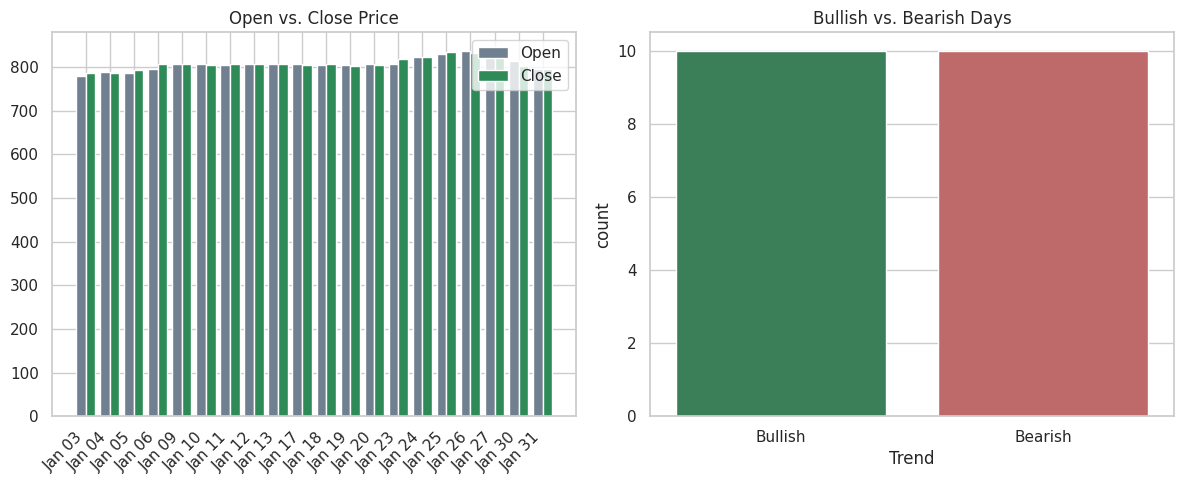

In [8]:
df['Trend'] = np.where(df['Close'] > df['Open'], 'Bullish', 'Bearish')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.arange(len(df))
axes[0].bar(x - 0.2, df['Open'], width=0.4, label='Open', color='slategray')
axes[0].bar(x + 0.2, df['Close'], width=0.4, label='Close', color='seagreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df['Date'].dt.strftime('%b %d'), rotation=45, ha='right')
axes[0].set_title('Open vs. Close Price')
axes[0].legend()

sns.countplot(x='Trend', data=df, palette={'Bullish': 'seagreen', 'Bearish': 'indianred'}, ax=axes[1])
axes[1].set_title('Bullish vs. Bearish Days')

plt.tight_layout()
plt.show()